# Homework 3 - Adversarial Attacks and Contrastive Learning

### Submission in pairs unless otherwise authorized
<ul>
<li> This notebook contains all the questions. You should follow the instructions below.</li>
<li> Solutions for both theoretical and practical parts should be written in this notebook</li>
</ul>

<h3> Moodle submission</h3>


<p>
You should submit three files:
</p>
<ul">
<li>IPYNB notebook:
  <ul>
  <li>All the wet and dry parts, including code, graphs, discussion, etc.</li>
  </ul>
</li>
<li>PDF file:
  <ul>
  <li>Export the notebook to PDF. Make sure that all the cells are visible.</li>
  </ul>
</li>
</ul>
<p>
All files should be in the following format: "HW3_ID1_ID2.file"
<br>
Good Luck!
</p>

Libraries that can be used in this assignment:

- PyTorch (torch, torchvision, torch.optim, torch.nn, ...) -- Any other deep learning libraries such as keras are prohibited
- NumPy
- Any libraries used for visualization
- PIL (for image processing)

For any libraries other than those listed above, you may ask in the forum.

## Part 1 - Training a CNN on SVHN

Train a classifier on the dataset SVHN (Street View House Numbers), available through ```torchvision.datasets```. The model accuracy should reach at least 90% on the test set. You're free to add as many data augmentations as necessary. Take into consideration that any serious augmentations (like normalization) should be reversed when displaying images in future sections.

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
from PIL import Image

# Data Augmentation
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),  # Randomly crop with padding
    transforms.RandomHorizontalFlip(),    # Randomly flip horizontally
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Adjust color properties
    transforms.RandomRotation(15),       # Random rotation within 15 degrees
    transforms.ToTensor(),               # Convert image to PyTorch tensor
    transforms.Normalize(mean=[0.4377, 0.4438, 0.4728], std=[0.198, 0.201, 0.197]),  # Normalize with SVHN stats
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3), value=0)  # Random erasing for occlusion
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4377, 0.4438, 0.4728], std=[0.198, 0.201, 0.197]),
])

train_dataset = datasets.SVHN(root='./data', split='train', download=True, transform=transform_train)
test_dataset = datasets.SVHN(root='./data', split='test', download=True, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


Using downloaded and verified file: ./data\train_32x32.mat
Using downloaded and verified file: ./data\test_32x32.mat


Epoch [1/12]
Train Loss: 2.1222 | Train Acc: 23.75%
Test Loss: 1.5026 | Test Acc: 48.85%
----------------------------------------
Epoch [2/12]
Train Loss: 1.5027 | Train Acc: 46.93%
Test Loss: 0.8456 | Test Acc: 73.07%
----------------------------------------
Epoch [3/12]
Train Loss: 1.1817 | Train Acc: 58.79%
Test Loss: 0.6352 | Test Acc: 80.29%
----------------------------------------
Epoch [4/12]
Train Loss: 1.0179 | Train Acc: 64.79%
Test Loss: 0.5002 | Test Acc: 84.60%
----------------------------------------
Epoch [5/12]
Train Loss: 0.8373 | Train Acc: 72.80%
Test Loss: 0.4211 | Test Acc: 87.77%
----------------------------------------
Epoch [6/12]
Train Loss: 0.7045 | Train Acc: 78.06%
Test Loss: 0.3697 | Test Acc: 89.01%
----------------------------------------
Epoch [7/12]
Train Loss: 0.6059 | Train Acc: 81.67%
Test Loss: 0.3296 | Test Acc: 90.37%
----------------------------------------
Epoch [8/12]
Train Loss: 0.5345 | Train Acc: 83.81%
Test Loss: 0.2878 | Test Acc: 92.07%
-

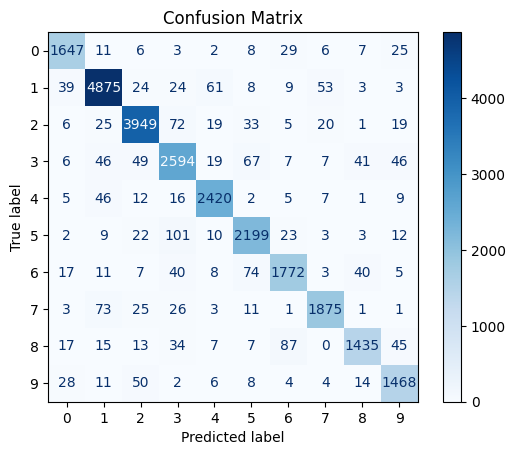


Displaying up to 5 incorrect predictions...


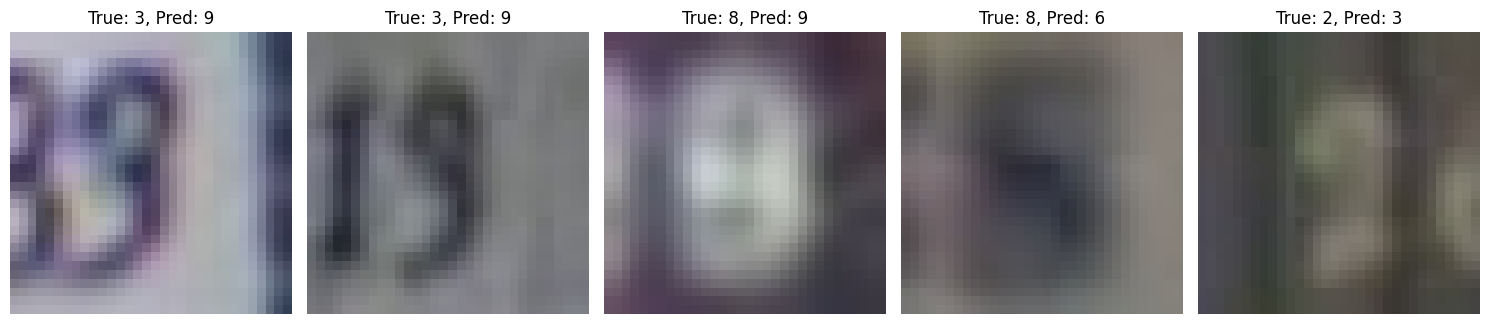

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import seaborn as sns
import copy
from torch.optim.lr_scheduler import CosineAnnealingLR

class OptimizedSVHNCNN(nn.Module):
    def __init__(self):
        super(OptimizedSVHNCNN, self).__init__()
        # First convolutional block - maintain spatial dimensions for small input
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        
        # Second convolutional block
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        
        # Third convolutional block
        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )
        
        # Initialize weights
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

def train_model(model, train_loader, test_loader, num_epochs=12):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)
    
    best_acc = 0.0
    best_model_state = None
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        
        # Testing phase
        model.eval()
        test_loss = 0
        correct = 0
        total = 0
        incorrect_samples = []  # To store incorrect predictions
        
        # Confusion matrix tracking
        all_true_labels = []
        all_predicted_labels = []
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                test_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
                
                # Append true and predicted labels for confusion matrix
                all_true_labels.extend(labels.cpu().numpy())
                all_predicted_labels.extend(predicted.cpu().numpy())
                
                # Store incorrect predictions
                for i in range(inputs.size(0)):
                    if predicted[i] != labels[i]:
                        incorrect_samples.append((inputs[i].cpu(), labels[i].item(), predicted[i].item()))
        
        test_loss = test_loss / len(test_loader)
        test_acc = 100. * correct / total
        
        # Save best model
        if test_acc > best_acc:
            best_acc = test_acc
            best_model_state = copy.deepcopy(model.state_dict())
        
        # Update scheduler
        scheduler.step()
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        
        print(f'Epoch [{epoch+1}/{num_epochs}]')
        print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
        print(f'Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%')
        print('----------------------------------------')
    
    # Final confusion matrix at the end of training
    cm = confusion_matrix(all_true_labels, all_predicted_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
    disp.plot(cmap='Blues')
    plt.title('Confusion Matrix')
    plt.show()
    
    # Load best model
    model.load_state_dict(best_model_state)
    # Mean and std from normalization
    mean = torch.tensor([0.4377, 0.4438, 0.4728]).view(3, 1, 1)  # Shape (C, H, W)
    std = torch.tensor([0.198, 0.201, 0.197]).view(3, 1, 1)

    # Undo normalization
    def denormalize(img):
        img = img * std + mean  # Undo normalization
        img = img.clamp(0, 1)   # Clip values to valid range [0,1]
        return img

    # Visualize incorrect predictions
    if incorrect_samples:
        print("\nDisplaying up to 5 incorrect predictions...")
        fig, axes = plt.subplots(1, min(len(incorrect_samples), 5), figsize=(15, 5))
        for i, (img, true_label, pred_label) in enumerate(incorrect_samples[:5]):
            img = denormalize(img)  # Apply denormalization
            img = img.permute(1, 2, 0)  # Convert (C, H, W) -> (H, W, C) for matplotlib
            
            axes[i].imshow(img.numpy())  # Convert to numpy array for display
            axes[i].set_title(f"True: {true_label}, Pred: {pred_label}")
            axes[i].axis('off')
        plt.tight_layout()
        plt.show()
    
    return model, history


# Initialize and train the model
model = OptimizedSVHNCNN()
model, history = train_model(model, train_loader, test_loader)

### Analysis

Analyze the performance of the model on the test set (e.g. through a confusion matrix). Display images that the model predicts incorrectly and their predicted classes. Discuss possible weaknesses of the model and their causes.

confusion matrix and images presented above.

## Part 2: Adversarial Attacks on our Model

Implement the FGSM algorithm as shown in the tutorial (it may be necessary to make require_grad be True for our input data in order to calculate its gradient). Define a function ```eval_adversarial(model, test_loader, epsilon)``` that applies FGSM on the test data by creating new images which are perturbed versions of the originals, and calculates the model's accuracy only on the perturbed images. Test accuracy after the attack should be less than 25% for $\varepsilon=0.1$.

### Visualization

Visualize some images that the model got right before the perturbation and wrong after the attack. Create a confusion matrix of the output on the entire test set.

Test the function with different values of epsilon (at least 5) and plot the accuracy as a function of epsilon. For each epsilon, display the perturbed images with the model's classification. At what epsilon does it become harder for the human eye to correctly classify?

FGSM Attack Performance Analysis

Analyzing Epsilon: 0.01


<Figure size 1000x800 with 0 Axes>

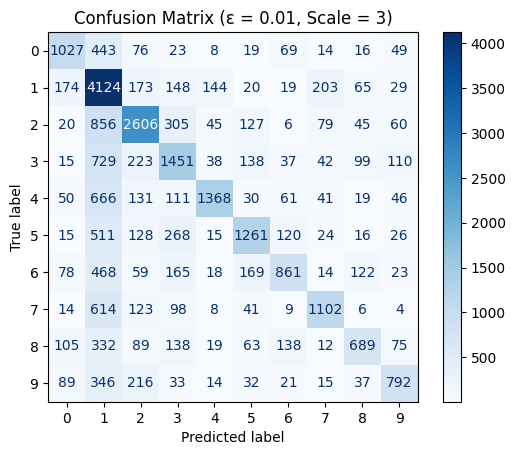

Epsilon: 0.01, Accuracy on Perturbed Data: 58.70%


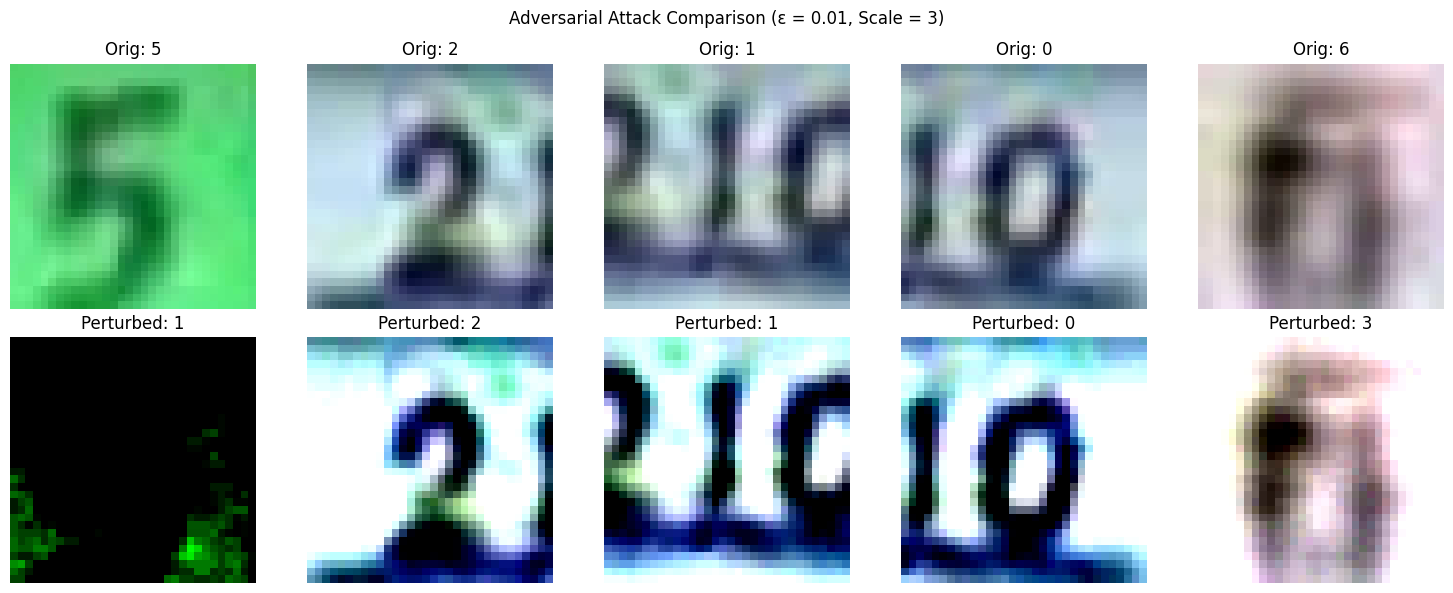


Analyzing Epsilon: 0.05


<Figure size 1000x800 with 0 Axes>

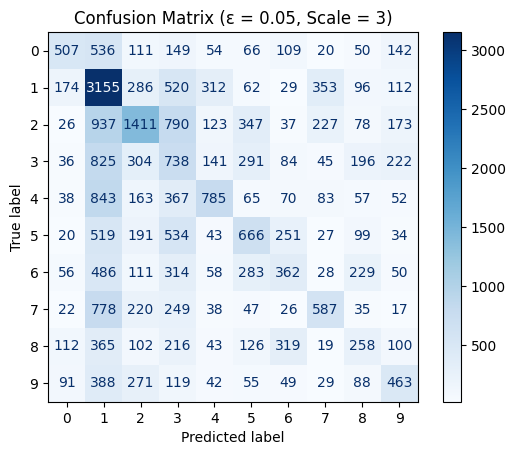

Epsilon: 0.05, Accuracy on Perturbed Data: 34.31%


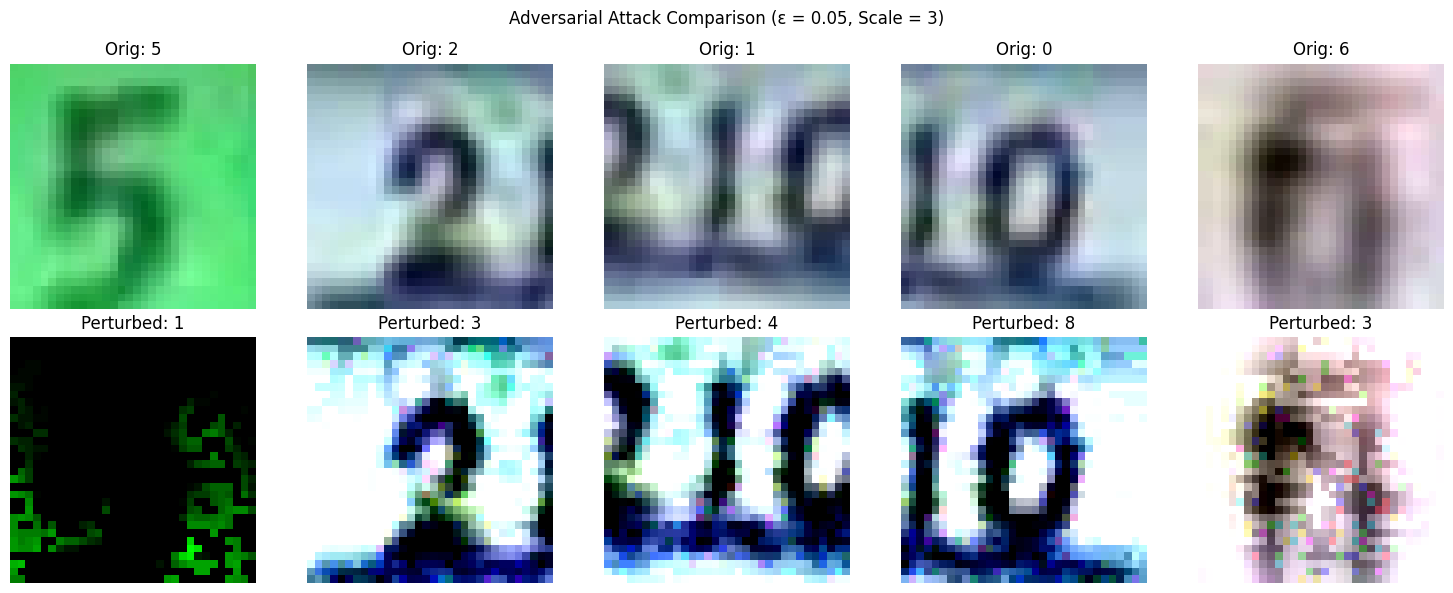


Analyzing Epsilon: 0.1


<Figure size 1000x800 with 0 Axes>

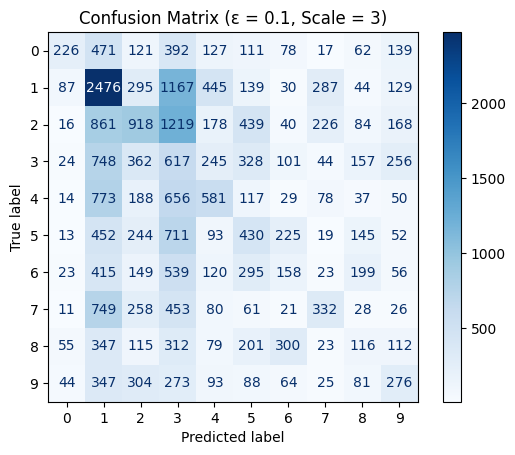

Epsilon: 0.1, Accuracy on Perturbed Data: 23.55%


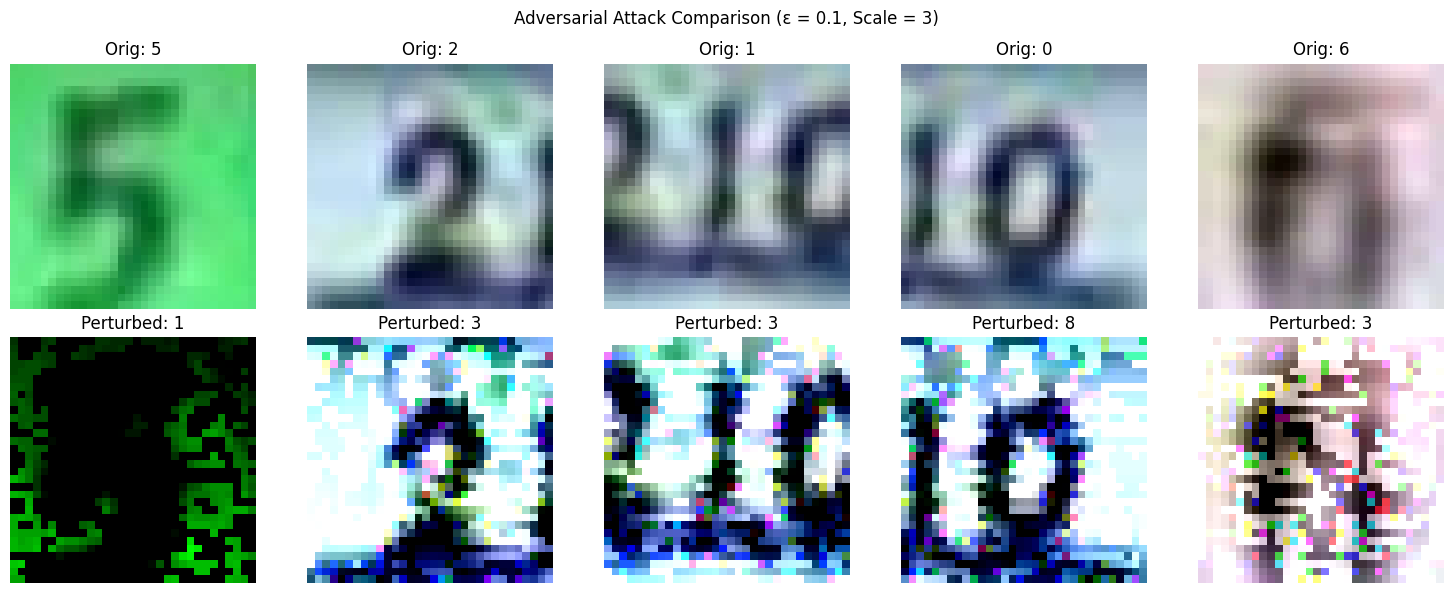


Analyzing Epsilon: 0.2


<Figure size 1000x800 with 0 Axes>

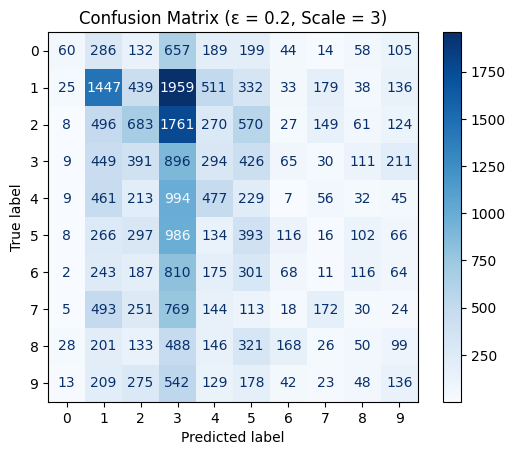

Epsilon: 0.2, Accuracy on Perturbed Data: 16.83%


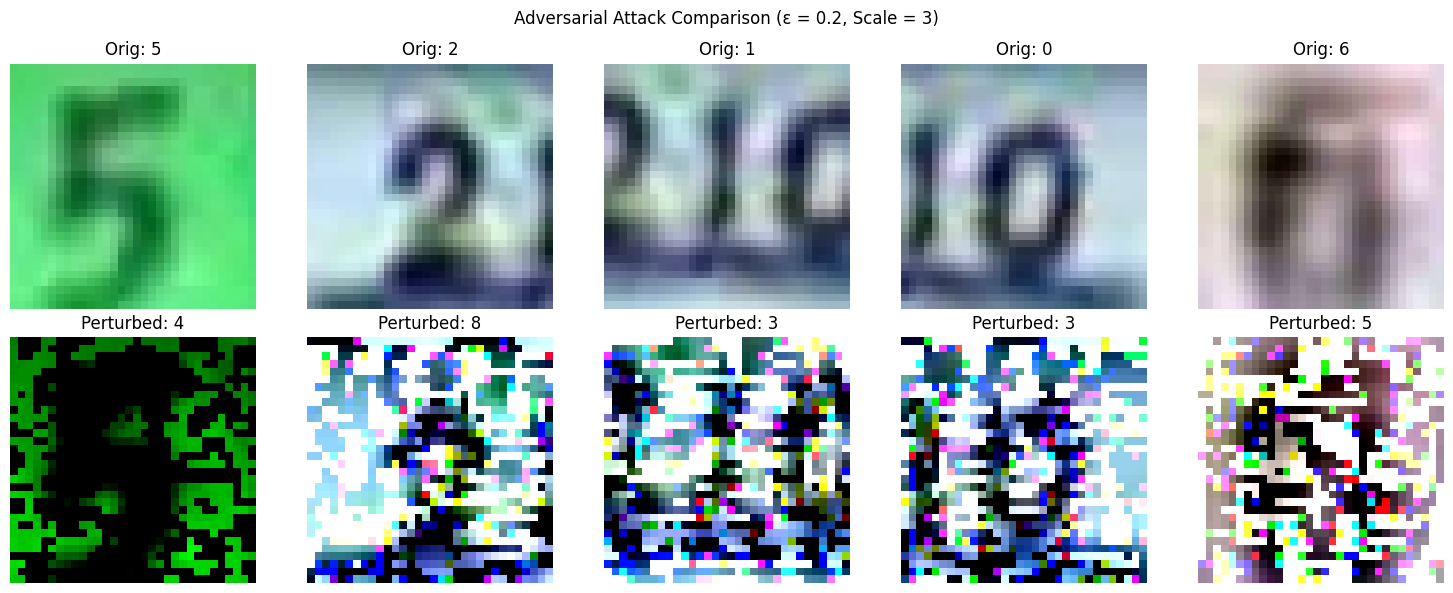


Analyzing Epsilon: 0.3


<Figure size 1000x800 with 0 Axes>

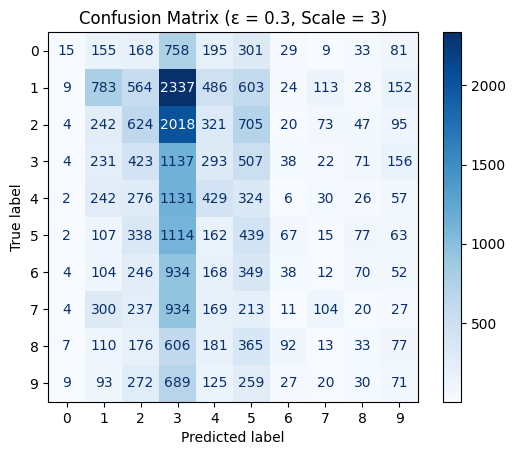

Epsilon: 0.3, Accuracy on Perturbed Data: 14.11%


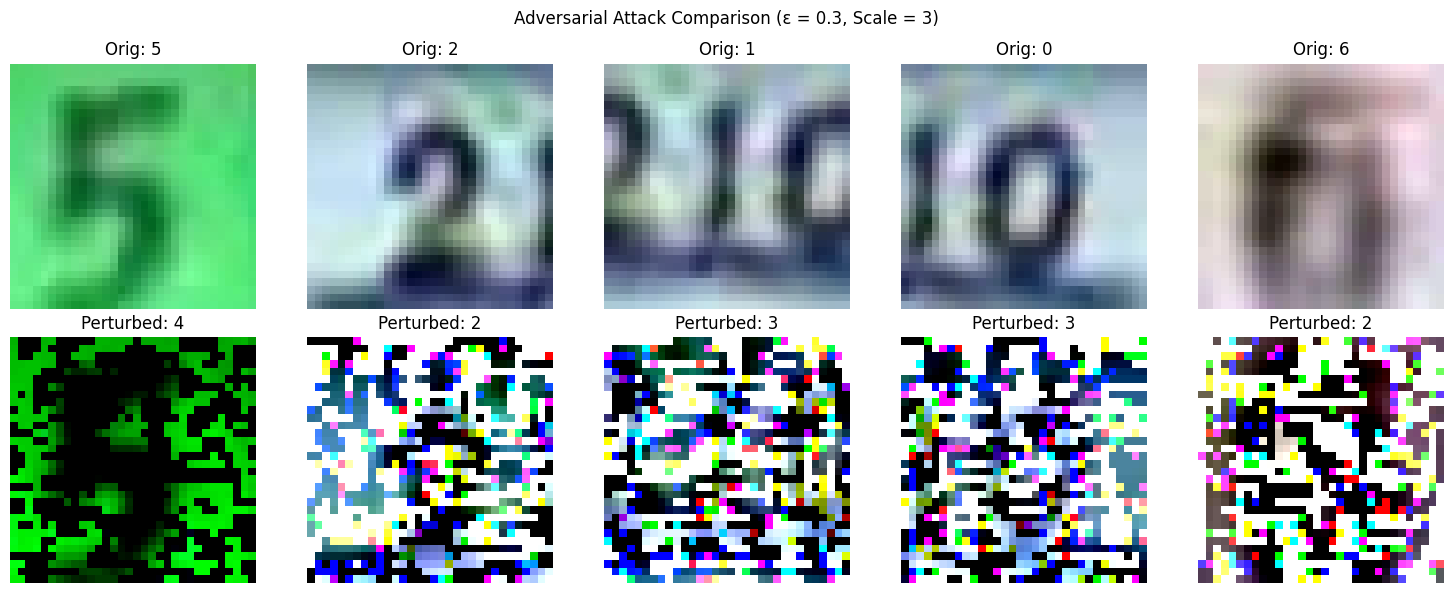

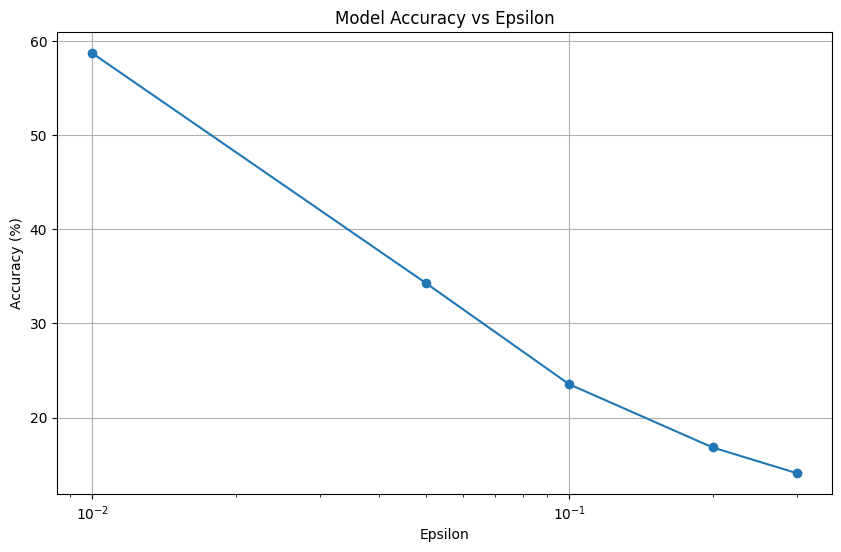


Epsilon Impact Analysis:
ε = 0.01: Accuracy = 58.70%
ε = 0.05: Accuracy = 34.31%
ε = 0.1: Accuracy = 23.55%
ε = 0.2: Accuracy = 16.83%
ε = 0.3: Accuracy = 14.11%


In [10]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def fgsm_attack(model, inputs, labels, epsilon):
    """
    Create adversarial examples using Fast Gradient Sign Method (FGSM) with a fixed scale of 3.
    """
    # Clone inputs and ensure gradient tracking
    inputs_clone = inputs.clone().detach().requires_grad_(True)
    
    # Forward pass
    outputs = model(inputs_clone)
    loss = nn.CrossEntropyLoss()(outputs, labels)
    
    # Compute gradients
    model.zero_grad()
    loss.backward()
    
    # Perturb inputs using the sign of the gradient
    scale = 3  # Maintained fixed scale as in original code
    perturbed_inputs = inputs + epsilon * scale * inputs_clone.grad.sign()
    
    # Clip to ensure we stay in valid image range
    perturbed_inputs = torch.clamp(perturbed_inputs, 0, 1)
    
    return perturbed_inputs

def visualize_attack_comparison(model, test_loader, epsilon):
    """
    Visualize images before and after adversarial attack with a fixed scale of 3.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    
    comparison_samples = []
    
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Original prediction
        with torch.no_grad():
            orig_outputs = model(inputs)
            _, orig_predicted = orig_outputs.max(1)
        
        # Generate perturbed inputs
        perturbed_inputs = fgsm_attack(model, inputs, labels, epsilon)
        
        # Perturbed prediction
        perturbed_outputs = model(perturbed_inputs)
        _, perturbed_predicted = perturbed_outputs.max(1)
        
        # Find interesting samples
        for i in range(inputs.size(0)):
            if orig_predicted[i] == labels[i]:
                comparison_samples.append({
                    'original_img': inputs[i].detach().cpu(),
                    'perturbed_img': perturbed_inputs[i].detach().cpu(),
                    'true_label': labels[i].item(),
                    'orig_pred': orig_predicted[i].item(),
                    'perturbed_pred': perturbed_predicted[i].item()
                })
            
            # Limit to 5 examples
            if len(comparison_samples) >= 5:
                break
        
        if len(comparison_samples) >= 5:
            break
    
    # Visualization
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    plt.suptitle(f'Adversarial Attack Comparison (ε = {epsilon}, Scale = 3)')
    
    for i, sample in enumerate(comparison_samples):
        # Original image
        orig_img = sample['original_img'].permute(1, 2, 0)
        orig_img = (orig_img - orig_img.min()) / (orig_img.max() - orig_img.min())
        axes[0, i].imshow(orig_img)
        axes[0, i].set_title(f'Orig: {sample["orig_pred"]}')
        axes[0, i].axis('off')
        
        # Perturbed image
        perturb_img = sample['perturbed_img'].permute(1, 2, 0)
        perturb_img = (perturb_img - perturb_img.min()) / (perturb_img.max() - perturb_img.min())
        axes[1, i].imshow(perturb_img)
        axes[1, i].set_title(f'Perturbed: {sample["perturbed_pred"]}')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

def eval_adversarial(model, test_loader, epsilon):
    """
    Evaluate model performance under FGSM attack with a fixed scale of 3.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    
    total = 0
    correct = 0
    all_true_labels = []
    all_predicted_labels = []
    
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Generate adversarial examples
        perturbed_inputs = fgsm_attack(model, inputs, labels, epsilon)
        
        # Predict on perturbed inputs
        outputs = model(perturbed_inputs)
        _, predicted = outputs.max(1)
        
        # Track performance
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Store labels for confusion matrix
        all_true_labels.extend(labels.cpu().numpy())
        all_predicted_labels.extend(predicted.cpu().numpy())
    
    accuracy = 100. * correct / total
    
    # Confusion Matrix
    cm = confusion_matrix(all_true_labels, all_predicted_labels)
    plt.figure(figsize=(10, 8))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10)).plot(cmap='Blues')
    plt.title(f'Confusion Matrix (ε = {epsilon}, Scale = 3)')
    plt.show()
    
    print(f'Epsilon: {epsilon}, Accuracy on Perturbed Data: {accuracy:.2f}%')
    return accuracy

def fgsm_attack_analysis(model, test_loader):
    """
    Analyze FGSM attack performance at various epsilon values with a fixed scale of 3.
    """
    # Epsilon values to test
    epsilons = [0.01, 0.05, 0.1, 0.2, 0.3]
    accuracies = []
    
    print("FGSM Attack Performance Analysis")
    
    # Epsilon sweep
    for eps in epsilons:
        print(f"\nAnalyzing Epsilon: {eps}")
        
        # Evaluate adversarial performance
        acc = eval_adversarial(model, test_loader, eps)
        accuracies.append(acc)
        
        # Visualize attack impact
        visualize_attack_comparison(model, test_loader, eps)
    
    # Plot accuracy vs epsilon
    plt.figure(figsize=(10, 6))
    plt.plot(epsilons, accuracies, marker='o')
    plt.title('Model Accuracy vs Epsilon')
    plt.xlabel('Epsilon')
    plt.ylabel('Accuracy (%)')
    plt.xscale('log')
    plt.grid(True)
    plt.show()
    
    # Identify epsilon impact
    print("\nEpsilon Impact Analysis:")
    for i, eps in enumerate(epsilons):
        print(f"ε = {eps}: Accuracy = {accuracies[i]:.2f}%")

# Run the analysis
fgsm_attack_analysis(model, test_loader)


## Part 3: Training our model using adversarial training

For each point in the training data, increase the model's robustness by training not only on the point itself, but on the perturbed point after the FGSM algorithm using $\varepsilon=0.1$. Afterwards, compute the accuracy once again on the newly trained model using ```eval_adversarial(model, test_loader, epsilon)``` defined above. The accuracy (LOOKING ONLY AT THE PERTURBED DATA) should be at least 70%. 

### Visualization

Display the confusion matrix along with some examples of images that the model classified incorrectly. Discuss the performance of the model now compared to before.

Starting Adversarial Robust Training...
Epoch [1/8], Loss: 1.2175, Accuracy: 58.99%
Epoch [2/8], Loss: 1.0336, Accuracy: 65.93%
Epoch [3/8], Loss: 0.8572, Accuracy: 72.19%
Epoch [4/8], Loss: 0.7932, Accuracy: 74.36%
Epoch [5/8], Loss: 0.7594, Accuracy: 75.46%
Epoch [6/8], Loss: 0.7165, Accuracy: 76.98%
Epoch [7/8], Loss: 0.6916, Accuracy: 77.78%
Epoch [8/8], Loss: 0.6700, Accuracy: 78.61%
Adversarial training complete.
Original Model Evaluation on Perturbed Data:


<Figure size 1000x800 with 0 Axes>

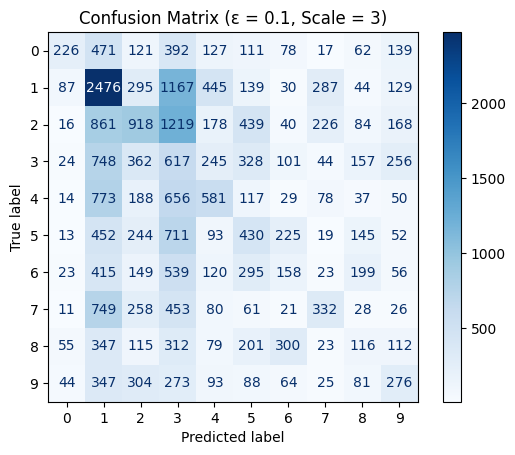

Epsilon: 0.1, Accuracy on Perturbed Data: 23.55%

Robust Model Evaluation on Perturbed Data:


<Figure size 1000x800 with 0 Axes>

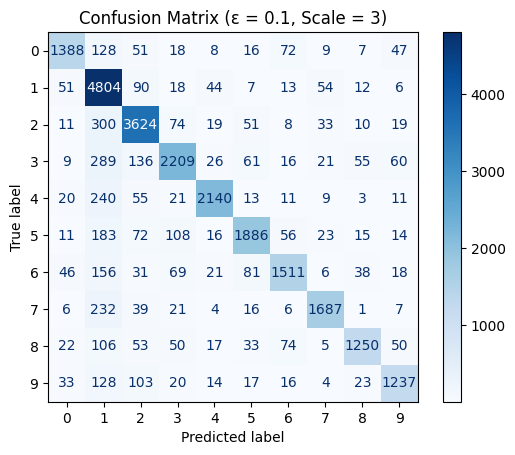

Epsilon: 0.1, Accuracy on Perturbed Data: 83.50%

Performance Summary:
Original Model Accuracy on Perturbed Data: 23.55%
Robust Model Accuracy on Perturbed Data: 83.50%

Visualizing Incorrect Predictions and Confusion Matrix...


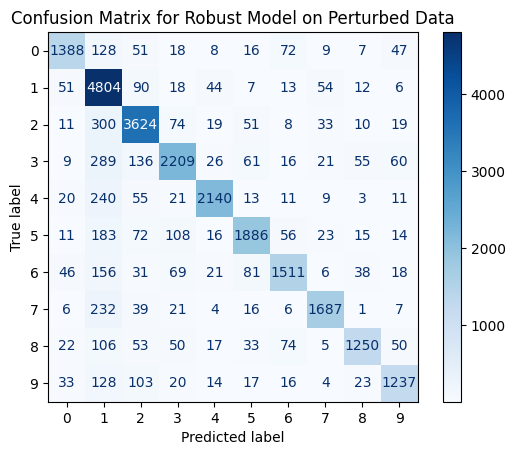

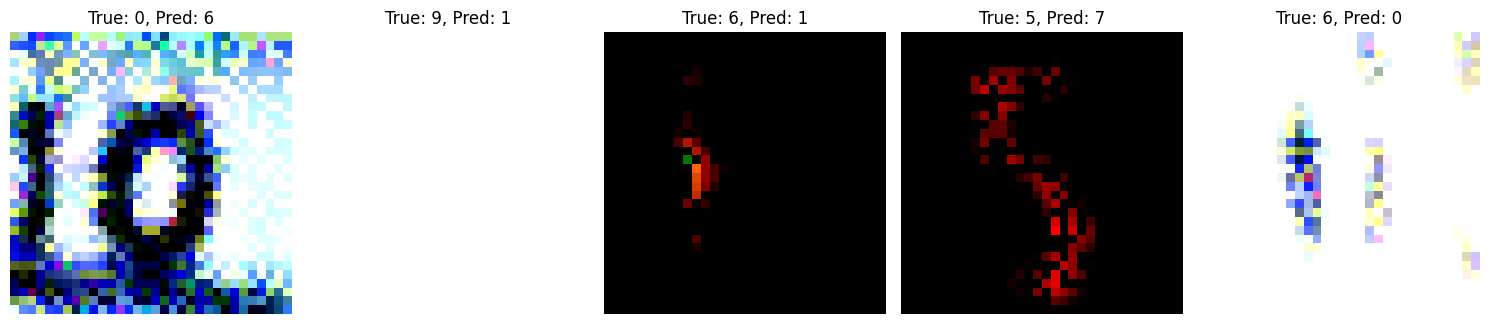

In [13]:
import torch
import torch.nn as nn
import copy
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


def robust_per_sample_training(model, train_loader, epsilon=0.1, epochs=8, learning_rate=0.001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.train()  # Ensure model is in training mode

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Ensure inputs require gradients
            inputs.requires_grad = True  # Ensure gradients are tracked
            
            # Generate adversarial examples
            perturbed_inputs = fgsm_attack(model, inputs, labels, epsilon)
            
            # Combine clean and adversarial examples
            combined_inputs = torch.cat([inputs, perturbed_inputs], dim=0)
            combined_labels = torch.cat([labels, labels], dim=0)

            optimizer.zero_grad()
            outputs = model(combined_inputs)

            loss = criterion(outputs, combined_labels)

            loss.backward(retain_graph=True)  # This prevents errors in multiple backward calls
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(combined_labels).sum().item()
            total += combined_labels.size(0)

        epoch_acc = 100. * correct / total
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}, Accuracy: {epoch_acc:.2f}%")

    print("Adversarial training complete.")
    return model



def evaluate_and_visualize_robust_model(original_model, robust_model, test_loader, epsilon=0.1):
    """
    Evaluate the original and robust model on adversarial examples and visualize results.
    """
    print("Original Model Evaluation on Perturbed Data:")
    original_acc = eval_adversarial(original_model, test_loader, epsilon)
    
    print("\nRobust Model Evaluation on Perturbed Data:")
    robust_acc = eval_adversarial(robust_model, test_loader, epsilon)
    
    print("\nPerformance Summary:")
    print(f"Original Model Accuracy on Perturbed Data: {original_acc:.2f}%")
    print(f"Robust Model Accuracy on Perturbed Data: {robust_acc:.2f}%")
    
    # Ensure robust accuracy meets the requirement
    assert robust_acc >= 70, f"Robustness requirement not met. Accuracy: {robust_acc:.2f}%"
    
    # Display misclassified examples and confusion matrix
    print("\nVisualizing Incorrect Predictions and Confusion Matrix...")
    visualize_misclassified_and_confusion_matrix(robust_model, test_loader, epsilon)
    
    return robust_acc


def visualize_misclassified_and_confusion_matrix(model, test_loader, epsilon):
    """
    Visualize misclassified examples and display the confusion matrix.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    
    incorrect_samples = []
    all_true_labels = []
    all_predicted_labels = []
    
    with torch.set_grad_enabled(True):  # Enable gradients for FGSM
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            perturbed_inputs = fgsm_attack(model, inputs, labels, epsilon)
            
            with torch.no_grad():  # Disable for prediction
                outputs = model(perturbed_inputs)
                _, predicted = outputs.max(1)
                
                for i in range(inputs.size(0)):
                    all_true_labels.append(labels[i].item())
                    all_predicted_labels.append(predicted[i].item())
                    
                    if predicted[i] != labels[i] and len(incorrect_samples) < 5:
                        incorrect_samples.append({
                            'img': perturbed_inputs[i].cpu(),
                            'true_label': labels[i].item(),
                            'pred_label': predicted[i].item()
                        })
    # Confusion Matrix
    cm = confusion_matrix(all_true_labels, all_predicted_labels)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10)).plot(cmap='Blues')
    plt.title("Confusion Matrix for Robust Model on Perturbed Data")
    plt.show()
    
    # Plot the misclassified images
    if incorrect_samples:
        fig, axes = plt.subplots(1, len(incorrect_samples), figsize=(15, 5))
        for i, sample in enumerate(incorrect_samples):
            img = sample['img'].permute(1, 2, 0)
            img = (img - img.min()) / (img.max() - img.min())
            axes[i].imshow(img)
            axes[i].set_title(f"True: {sample['true_label']}, Pred: {sample['pred_label']}")
            axes[i].axis('off')
        plt.tight_layout()
        plt.show()


def perform_robust_training(model, train_loader, test_loader, epsilon=0.1):
    robust_model = copy.deepcopy(model)
    robust_model = robust_per_sample_training(robust_model, train_loader, epsilon=epsilon, epochs=8)
    evaluate_and_visualize_robust_model(model, robust_model, test_loader, epsilon=epsilon)
    return robust_model


# Run Robust Training
print("Starting Adversarial Robust Training...")
robust_model = perform_robust_training(model, train_loader, test_loader, epsilon=0.1)

## Part 4: Contrastive Learning

In this section, we will work on creating informative embeddings for images using SimCLR. For this section we will use the attached subset of the popular ImageNet dataset of 96x96 images from 1000 classes. Below, we provide you with several functions to implement a contrastive learning model.

### Dry Questions

Before implementation, take these questions in consideration (and provide your answers and explanations):

1. When training an unsupervised contrastive learning model such as SimCLR, would we prefer to have a large or small batch size?
2. In general, what possible evaluation metrics could be used in this task (unsupervised representation learning) to measure our model's performance?
3. For each of the following image augmentations, explain whether or not we would like to use them in the SimCLR framework:
    - Randomly cropping a fixed-size window in the image.
    - Enlarging the image to 128x128.
    - Random rotation of the image.
    - Adding Gaussian noise.
    - Randomly changing the image's dimensions
    - Randomly converting the image to grayscale.

### Code

Do the following:

1. Create a CNN that makes embeddings for images (you can use pretrained foundation models if you'd like).
2. Implement any unsupervised contrastive loss (such as nt-xent in SimCLR).
3. Train the model (achieve loss less than 3.0).

In [2]:
from PIL import Image
import os
import torch
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox  # For visualization
from sklearn.manifold import TSNE  # Dimensionality Reduction
# Define paths

TEST_PATH = r'C:\Users\hilal\OneDrive - Technion\Notability\סמסטר ה׳ תשפ״ה\0970209 למידה חישובית 2\תרגילי בית\HW3\tiny-imagenet-200\test'
TRAIN_PATH= r'C:\Users\hilal\OneDrive - Technion\Notability\סמסטר ה׳ תשפ״ה\0970209 למידה חישובית 2\תרגילי בית\HW3\tiny-imagenet-200\train'

BATCH_SIZE = 4096  # ADD YOUR BATCH SIZE HERE, BASED ON YOUR ANSWER TO THE DRY QUESTIONS

In [4]:
from torchvision import transforms
from torch.utils.data import DataLoader

class TrainDataset(torch.utils.data.Dataset):
    def __init__(self, root, transform=None):
        """
        Initialize the dataset with the root directory and the transform to be applied.
        """
        self.root = root
        self.transform = transform
        self.imgs = []
        for label in os.listdir(root):
            if os.path.isdir(os.path.join(root, label, 'images')):
                for img in os.listdir(os.path.join(root, label, 'images')):
                    self.imgs.append(os.path.join(root, label, 'images', img))

    def __len__(self):
        """
        Return the length of the dataset.
        """
        return len(self.imgs)

    def __getitem__(self, idx):
        """
        Fetch the image and apply two different augmentations to it.
        """
        img_path = self.imgs[idx]
        img = Image.open(img_path).convert('RGB')  # Ensure it's in RGB format

        if self.transform:
            img1 = self.transform(img)  # First random augmentation
            img2 = self.transform(img)  # Second random augmentation
        else:
            img1, img2 = img, img

        return img1, img2  # Return both augmented versions


class TestDataset(torch.utils.data.Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.imgs = []
        for label in os.listdir(root):
            for img in os.listdir(os.path.join(root, label)):
                self.imgs.append(os.path.join(root, label, img))

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_path = self.imgs[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img_transform = self.transform(img)
        return transforms.ToTensor()(img), img_transform  # Return the original image (for visualization) and the image that will be used in the model



data_transforms = transforms.Compose([
    transforms.RandomResizedCrop(96, scale=(0.5, 1.0)),  # Randomly crop and resize the image
    transforms.RandomHorizontalFlip(p=0.5),  # Randomly flip the image horizontally
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.1)  # Randomly change brightness, contrast, and saturation
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),  # Randomly convert image to grayscale
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),  # Apply Gaussian Blur randomly
    transforms.ToTensor(),  # Convert the image to a tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize with ImageNet stats
])

test_transforms = transforms.Compose([
    transforms.Resize(100),  # Resize images slightly larger than the crop size
    transforms.CenterCrop(96),  # Crop the images to the same size as training
    transforms.ToTensor(),  # Convert the image to a tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize with ImageNet stats
])
train_data = TrainDataset(TRAIN_PATH, transform=data_transforms)  
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

test_data = TestDataset(TEST_PATH, transform=test_transforms)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

Using the function ```plot_embeddings```, show the model's performance on the test data. 

In [6]:
def plot_embeddings(model, test_loader, device):
    """
    This function creates embeddings for each image in the first batch of the test loader, projects them to 2D and displays them on a plot.
    """
    for img, img_transform in test_loader:
        img_transform = img_transform.to(device)
        embeddings = model(img_transform)
        tsne = TSNE(n_components=2)
        embeddings = tsne.fit_transform(embeddings.cpu().detach().numpy())

        fig, ax = plt.subplots()
        ax.set_xlim(-5, 5)
        ax.set_ylim(-5, 5)
        for i in range(embeddings.shape[0]):
            curr_img = img[i].permute(1,2,0)
            curr_img = OffsetImage(curr_img, zoom=0.5)
            ab = AnnotationBbox(curr_img, embeddings[i], frameon=False)
            ax.add_artist(ab)
        plt.show()
        return

In [7]:
## Create a CNN for Image Embeddings
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import efficientnet_b0  # Importing the base model

class ImageEmbeddingNet(nn.Module):
    def __init__(self):  # Corrected __init__ method
        super(ImageEmbeddingNet, self).__init__()
        self.base_model = efficientnet_b0(pretrained=False)  # Ensure pretrained is set to False
        self.embedding_layer = nn.Linear(self.base_model.classifier[1].in_features, 128)  # Custom embedding size
        self.base_model.classifier = nn.Identity()  # Remove the classifier

    def forward(self, x):
        features = self.base_model(x)
        embeddings = self.embedding_layer(features)
        return embeddings

## Implement Unsupervised Contrastive Loss (NT-Xent)
class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):  # Corrected __init__ method
        super(NTXentLoss, self).__init__()
        self.temperature = temperature
        self.cosine_similarity = nn.CosineSimilarity(dim=-1)

    def forward(self, z_i, z_j):
        """
        Calculate the NT-Xent loss between two sets of embeddings.
        """
        z_i = nn.functional.normalize(z_i, dim=1)
        z_j = nn.functional.normalize(z_j, dim=1)
        representations = torch.cat([z_i, z_j], dim=0)
        similarity_matrix = self.cosine_similarity(
            representations.unsqueeze(1), representations.unsqueeze(0)
        ) / self.temperature
        sim_ij = torch.diag(similarity_matrix, z_i.shape[0])
        sim_ji = torch.diag(similarity_matrix, -z_i.shape[0])
        positives = torch.cat([sim_ij, sim_ji], dim=0)
        negatives_mask = ~torch.eye(
            similarity_matrix.shape[0], dtype=torch.bool, device=similarity_matrix.device
        )
        negatives = similarity_matrix[negatives_mask].reshape(similarity_matrix.shape[0], -1)
        loss = -torch.log(positives / (positives.sum(-1) + negatives.sum(-1)))
        return loss.mean()

## Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ImageEmbeddingNet().to(device)  # No error with __init__ corrected
optimizer = optim.Adam(model.parameters(), lr=1e-4)
loss_fn = NTXentLoss(temperature=0.1)  # Adjust temperature if needed
epochs = 10  # Set according to your computational budget

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for (img1, img2) in train_loader:
        img1, img2 = img1.to(device), img2.to(device)
        optimizer.zero_grad()
        z_i = model(img1)
        z_j = model(img2)
        loss = loss_fn(z_i, z_j)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f'Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}')

    # Call the plot_embeddings function after every epoch
    print(f"Visualizing embeddings after epoch {epoch+1}...")
    plot_embeddings(model, test_loader, device)

    # Early stopping condition
    if total_loss / len(train_loader) < 3.0:  # Check if loss is below the threshold
        print("Training complete with acceptable loss.")
        break


C:\Users\hilal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\hilal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


: 

For some batch of the test loader, take 3 images in the batch. For each image, find and display the 5 images that have the closest embeddings to them. Do the chosen images make sense? If not, what could have possibly gone wrong with your model?